In [1]:
# Import initial libraries
import pandas as pd
import numpy as np
import boto3
from io import StringIO
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Test 2: Connect to S3
s3 = boto3.client('s3')
response = s3.list_buckets()
bucket_count = len(response['Buckets'])

print(f"Connected to S3")
print(f"Found {bucket_count} S3 buckets")

# Print your buckets (to identify your modeling data bucket)
for bucket in response['Buckets']:
    print(f"  - {bucket['Name']}")

Connected to S3
Found 1 S3 buckets
  - cmse492-huntbrendan-nyc311-767397988837-us-east-1-an


In [3]:
# Load your modeling dataset from S3
# Replace the path below with your actual S3 path from Day 26
s3 = boto3.client('s3')
bucket_name = 'cmse492-huntbrendan-nyc311-767397988837-us-east-1-an' # replace with your bucket name (make sure you have the account regional suffix)
file_name = 'modeling/modeling_data.csv' # make sure to include the path if it's in a folder, e.g. 'modeling/modeling_data.csv'

obj = s3.get_object(Bucket=bucket_name, Key=file_name)
data = obj['Body'].read().decode('utf-8')
df = pd.read_csv(StringIO(data))

print(f"Shape: {df.shape}")
df.head()

Shape: (173870, 8)


,agency,borough,problem,incident_zip,day_of_week,hour_of_day,problem_category,resolved_quickly
0,NYPD,BRONX,Noise - Commercial,10473.0,2,11,noise,1
1,DPR,BROOKLYN,Damaged Tree,11213.0,2,11,other,1
2,DEP,MANHATTAN,Noise,10028.0,2,11,noise,1
3,HPD,BROOKLYN,ELECTRIC,11226.0,2,11,housing,0
4,HPD,BROOKLYN,UNSANITARY CONDITION,11226.0,2,11,housing,0


In [4]:
# Quick data check — confirm the shape, column names, and target variable
print("Columns:", df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())
print("\nData types:")
print(df.dtypes)

Columns: ['agency', 'borough', 'problem', 'incident_zip', 'day_of_week', 'hour_of_day', 'problem_category', 'resolved_quickly']

Missing values:
agency                 0
borough                0
problem                0
incident_zip        1768
day_of_week            0
hour_of_day            0
problem_category       0
resolved_quickly       0
dtype: int64

Data types:
agency               object
borough              object
problem              object
incident_zip        float64
day_of_week           int64
hour_of_day           int64
problem_category     object
resolved_quickly      int64
dtype: object


In [18]:
# Define feature columns and target columnborough
df['incident_zip'] = df['incident_zip'].fillna(0).astype(int).astype(str).replace('0', 'unknown')

# 2. Select your feature set
feature_cols = [
    'agency', 
    'borough', 
    'problem_category', 
    'day_of_week', 
    'hour_of_day', 
    'incident_zip'
]

X = df[feature_cols]
y = df['resolved_quickly']
target_col = 'resolved_quickly'          # <-- update this

# If your target needs to be binarized or modified in some way, do it here
# Example: df['high_volume'] = (df['volume_quartile'] == 1).astype(int)

X = df[feature_cols]
y = df[target_col]
print(f"Features: {feature_cols}")
print(f"Target: {target_col}")
print(f"\nTarget distribution:")
print(y.value_counts())
print(f"\nClass balance: {y.value_counts(normalize=True).round(3).to_dict()}")

Features: ['agency', 'borough', 'problem_category', 'day_of_week', 'hour_of_day', 'incident_zip']
Target: resolved_quickly

Target distribution:
resolved_quickly
1    146158
0     27712
Name: count, dtype: int64

Class balance: {1: 0.841, 0: 0.159}


In [19]:
# Import train_test_split for splitting the data
from sklearn.model_selection import train_test_split

# Train/test split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set:  {X_train.shape[0]} rows")
print(f"Test set:      {X_test.shape[0]} rows")
print(f"\nClass balance in training set:")
print(y_train.value_counts(normalize=True).round(3))
print(f"\nClass balance in test set:")
print(y_test.value_counts(normalize=True).round(3))

Training set:  139096 rows
Test set:      34774 rows

Class balance in training set:
resolved_quickly
1    0.841
0    0.159
Name: proportion, dtype: float64

Class balance in test set:
resolved_quickly
1    0.841
0    0.159
Name: proportion, dtype: float64


In [20]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

# Identify categorical vs. numeric columns automatically
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X.select_dtypes(include=['number']).columns.tolist()

print(f"Categorical columns ({len(cat_cols)}): {cat_cols}")
print(f"Numeric columns     ({len(num_cols)}): {num_cols}")

# Build the transformer:
#   - OneHotEncoder for categorical columns
#     drop='first'         avoids multicollinearity (k-1 dummies per feature)
#     sparse_output=False  returns a regular numpy array (easier to inspect)
#     handle_unknown='ignore'  silently zeros out categories not seen in training
#   - StandardScaler for numeric columns (optional but often helpful for models like Logistic Regression)
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_cols),
        ('num', StandardScaler(), num_cols),  # scale numeric columns
    ]
)

# Fit ONLY on training data, then apply to both splits
X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc  = preprocessor.transform(X_test)

# Recover feature names for later coefficient inspection
ohe_names = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols).tolist()
encoded_feature_names = ohe_names + num_cols

print(f"\nEncoded feature matrix shape: {X_train_enc.shape}")
print(f"Total features after encoding: {len(encoded_feature_names)}")
print(f"\nFirst few encoded feature names: {encoded_feature_names[:10]}")

Categorical columns (4): ['agency', 'borough', 'problem_category', 'incident_zip']
Numeric columns     (2): ['day_of_week', 'hour_of_day']

Encoded feature matrix shape: (139096, 237)
Total features after encoding: 237

First few encoded feature names: ['agency_DEP', 'agency_DHS', 'agency_DOB', 'agency_DOE', 'agency_DOHMH', 'agency_DOT', 'agency_DPR', 'agency_DSNY', 'agency_HPD', 'agency_NYPD']


/home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [21]:
# Import the logistic regression model
from sklearn.linear_model import LogisticRegression

# 'balanced' automatically calculates weights inversely proportional to class frequencies
model = LogisticRegression(class_weight='balanced')
model.fit(X_train_enc, y_train)

print("Model trained successfully.")
print(f"Classes: {model.classes_}")

Model trained successfully.
Classes: [0 1]


In [22]:
# Inspect the model coefficients
# After encoding, use encoded_feature_names instead of feature_cols
coef_df = pd.DataFrame({
    'feature': encoded_feature_names,
    'coefficient': model.coef_[0]
}).sort_values('coefficient', ascending=False)

print("Model coefficients (top 10 by magnitude):")
print(coef_df.head(10).to_string(index=False))
print("\nPositive coefficient = feature pushes toward the positive class")
print("Negative coefficient = feature pushes toward the negative class")

Model coefficients (top 10 by magnitude):
             feature  coefficient
         agency_NYPD     9.356141
          agency_DEP     1.661270
        agency_DOHMH     1.541957
          agency_DHS     1.472999
  incident_zip_11430     1.301195
         agency_DSNY     1.189587
  incident_zip_10004     0.977317
          agency_DOE     0.913547
          agency_DOB     0.830942
incident_zip_unknown     0.704128

Positive coefficient = feature pushes toward the positive class
Negative coefficient = feature pushes toward the negative class


In [23]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Generate predictions on the test set
y_pred = model.predict(X_test_enc)

# Compute metrics
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)

print(f"Accuracy:  {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall:    {rec:.3f}")

Accuracy:  0.681
Precision: 0.968
Recall:    0.643


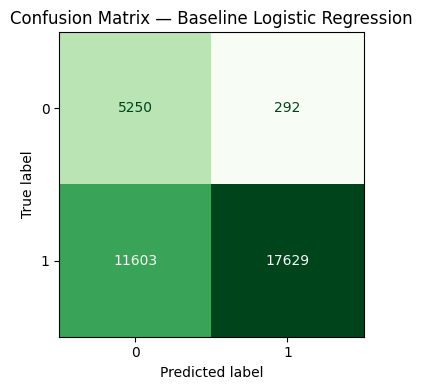

Confusion matrix saved to confusion_matrix.png


In [17]:
# Plot the confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)

fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title('Confusion Matrix — Baseline Logistic Regression')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120)
plt.show()
print("Confusion matrix saved to confusion_matrix.png")